<a href="https://colab.research.google.com/github/carlos31255/EV1_Machine_learning/blob/main/notebooks/EV1_Spotify.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EP1 - Machine Learning (MLY1101)
## Caso C: Inteligencia musical y predicción de popularidad de canciones (Spotify Tracks)

### Análisis Exploratorio de Datos (EDA)

Este notebook documenta el Análisis Exploratorio de Datos (EDA) del dataset **Spotify Tracks Dataset** (114,000 canciones), como parte del desarrollo del proyecto de Machine Learning bajo la metodología **CRISP-DM**, en su fase de *Comprensión de los Datos* (Data Understanding).

**Objetivos de este EDA:**
1. Cargar y describir la estructura general del dataset.
2. Evaluar la **calidad de los datos** (nulos, duplicados, tipos, inconsistencias).
3. Analizar la **distribución de la variable objetivo** (`popularity`).
4. Realizar análisis **univariado** de variables numéricas y categóricas relevantes.
5. Identificar **anomalías y outliers**.
6. Analizar **correlaciones** y relaciones bivariadas relevantes para el problema de negocio.
7. Sintetizar hallazgos que justifiquen las decisiones de preparación de datos (siguiente etapa CRISP-DM).


---

##  Fuentes de Datos y Herramientas Colaborativas

### Dataset utilizado

| Atributo | Detalle |
|----------|--------|
| **Nombre** | Spotify Tracks Dataset |
| **Autor** | Maharshi Pandya |
| **Fuente original** | [Kaggle — maharshipandya/spotify-tracks-dataset](https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset) |
| **Mirror de carga** | [Hugging Face Hub](https://huggingface.co/datasets/maharshipandya/spotify-tracks-dataset) |
| **Tamaño** | ~9 MB — 114,000 canciones — 21 columnas |
| **Licencia** | Pública, uso académico libre |

**Justificación del mirror:** Se carga el dataset desde Hugging Face en lugar de Kaggle directamente, ya que permite acceso público sin credenciales. Esto garantiza que el notebook sea completamente reproducible tanto en entorno local como en Google Colab sin configuración adicional.

---

### Herramientas colaborativas utilizadas

| Herramienta | Rol en el proyecto | Justificación |
|-------------|-------------------|---------------|
| **GitHub** | Control de versiones y repositorio central | Permite trabajo colaborativo, historial de cambios y reproducibilidad. [Ver repositorio](https://github.com/carlos31255/EV1_Machine_learning) |
| **Google Colab** | Ejecución del notebook en la nube | Sin instalación local; cualquier integrante puede ejecutar el notebook desde un navegador. Ideal para compartir y presentar. |
| **Jupyter Notebook** | Desarrollo local interactivo | Permite combinar código, visualizaciones y texto (Markdown) en un solo documento ejecutable. |
| **Hugging Face Hub** | Hosting del dataset | Mirror público del dataset sin requerir credenciales de Kaggle. |
| **Discord** | Comunicación y coordinación del equipo | Canal asíncrono para coordinar tareas y decisiones del proyecto. |

---

In [1]:
# Librerías principales de manipulación y cálculo
import pandas as pd
import numpy as np
import os

# Asegurar que el directorio de trabajo sea la raíz del proyecto
# (necesario para que nbconvert y VS Code usen las mismas rutas)
import pathlib
REPO_ROOT = pathlib.Path(__file__).parent if '__file__' in dir() else pathlib.Path.cwd()
# Sube hasta encontrar EV1_Spotify.ipynb
for parent in [REPO_ROOT] + list(REPO_ROOT.parents):
    if (parent / 'requirements.txt').exists() or (parent / '.git').exists():
        os.chdir(parent)
        break

# Librerías de visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning y Preprocesamiento
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Configuración general
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
plt.rcParams['figure.dpi'] = 100

# Semilla global para reproducibilidad
SEED = 42

# Carpetas necesarias
os.makedirs('data/raw', exist_ok=True)
os.makedirs('data/processed', exist_ok=True)
os.makedirs('images', exist_ok=True)

# Carga del dataset con caché local
LOCAL_CSV = 'data/raw/Spotify_Tracks_Dataset.csv'
URL = "https://huggingface.co/datasets/maharshipandya/spotify-tracks-dataset/resolve/main/dataset.csv"

if os.path.exists(LOCAL_CSV):
    df = pd.read_csv(LOCAL_CSV)
    print(f"Dataset cargado desde caché local: {df.shape[0]:,} filas x {df.shape[1]} columnas")
else:
    print("Descargando dataset de HuggingFace...")
    df = pd.read_csv(URL)
    df.to_csv(LOCAL_CSV, index=False)
    print(f"Dataset descargado y guardado en {LOCAL_CSV}")

if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

print(f"Directorio de trabajo: {os.getcwd()}")
df.head()

Dataset cargado desde caché local: 114,000 filas x 21 columnas
Directorio de trabajo: c:\Users\Carlos\Desktop\DUOC\Machine Learning\EV1


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          114000 non-null  str    
 1   artists           113999 non-null  str    
 2   album_name        113999 non-null  str    
 3   track_name        113999 non-null  str    
 4   popularity        114000 non-null  int64  
 5   duration_ms       114000 non-null  int64  
 6   explicit          114000 non-null  bool   
 7   danceability      114000 non-null  float64
 8   energy            114000 non-null  float64
 9   key               114000 non-null  int64  
 10  loudness          114000 non-null  float64
 11  mode              114000 non-null  int64  
 12  speechiness       114000 non-null  float64
 13  acousticness      114000 non-null  float64
 14  instrumentalness  114000 non-null  float64
 15  liveness          114000 non-null  float64
 16  valence           114000 non-nu

## 2. Calidad de los datos

En esta sección se evalúa la calidad de los datos: valores nulos, filas/registros duplicados, consistencia de tipos y valores fuera de rango, en línea con el indicador **IE3 (Análisis exploratorio y calidad de los datos)** de la pauta.

### 2.1 Valores nulos / faltantes


In [3]:
nulos = df.isnull().sum()
porcentaje_nulos = (nulos / len(df)) * 100
tabla_nulos = pd.DataFrame({'Cantidad de Nulos': nulos, 'Porcentaje de Nulos': porcentaje_nulos})
tabla_nulos = tabla_nulos.sort_values(by='Porcentaje de Nulos', ascending=False)
display(tabla_nulos)

,Cantidad de Nulos,Porcentaje de Nulos
artists,1,0.000877
album_name,1,0.000877
track_name,1,0.000877
track_id,0,0.000000
popularity,0,0.000000
duration_ms,0,0.000000
explicit,0,0.000000
danceability,0,0.000000
energy,0,0.000000
key,0,0.000000


### 2.2 Registros duplicados

In [4]:
# Duplicados exactos (todas las columnas)
duplicados_totales = df.duplicated().sum()
print(f"Cantidad de duplicados totales: {duplicados_totales}")

# Duplicados por track_id (misma canción registrada más de una vez, ej. distintas versiones/álbumes)
dup_track_id = df.duplicated(subset=['track_id']).sum()
print(f"Registros con track_id duplicado: {dup_track_id} ({dup_track_id/len(df)*100:.2f}%)")

Cantidad de duplicados totales: 450
Registros con track_id duplicado: 24259 (21.28%)


In [5]:
# Inspección de un caso de track_id duplicado para entender el patrón
ejemplo_id = df[df.duplicated(subset=['track_id'], keep=False)]['track_id'].iloc[0]
df[df['track_id'] == ejemplo_id][['track_id', 'track_name', 'artists', 'album_name', 'track_genre', 'popularity']].head(10)

,track_id,track_name,artists,album_name,track_genre,popularity
0,5SuOikwiRyPMVoIQDJUgSV,Comedy,Gen Hoshino,Comedy,acoustic,73
62102,5SuOikwiRyPMVoIQDJUgSV,Comedy,Gen Hoshino,Comedy,j-pop,73
99152,5SuOikwiRyPMVoIQDJUgSV,Comedy,Gen Hoshino,Comedy,singer-songwriter,73
102151,5SuOikwiRyPMVoIQDJUgSV,Comedy,Gen Hoshino,Comedy,songwriter,73


**Hallazgo:** una misma canción (`track_id`) puede aparecer repetida en distintos `track_genre`, ya que Spotify clasifica la misma pista bajo múltiples géneros/playlists. Esto es relevante para la etapa de preparación de datos (decidir si se conserva una fila por canción o si se analiza a nivel canción-género).

In [6]:
# Estadística descriptiva de variables numéricas
df.describe().T

,count,mean,std,min,25%,50%,75%,max
popularity,114000.0,33.238535,22.305078,0.000,17.00000,35.000000,50.0000,100.000
duration_ms,114000.0,228029.153114,107297.712645,0.000,174066.00000,212906.000000,261506.0000,5237295.000
danceability,114000.0,0.566800,0.173542,0.000,0.45600,0.580000,0.6950,0.985
energy,114000.0,0.641383,0.251529,0.000,0.47200,0.685000,0.8540,1.000
key,114000.0,5.309140,3.559987,0.000,2.00000,5.000000,8.0000,11.000
loudness,114000.0,-8.258960,5.029337,-49.531,-10.01300,-7.004000,-5.0030,4.532
mode,114000.0,0.637553,0.480709,0.000,0.00000,1.000000,1.0000,1.000
speechiness,114000.0,0.084652,0.105732,0.000,0.03590,0.048900,0.0845,0.965
acousticness,114000.0,0.314910,0.332523,0.000,0.01690,0.169000,0.5980,0.996
instrumentalness,114000.0,0.156050,0.309555,0.000,0.00000,0.000042,0.0490,1.000


In [7]:
# Verificación de rangos esperados para variables normalizadas (0 a 1)
cols_0_1 = ['danceability', 'energy', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'mode']
for col in cols_0_1:
    fuera_de_rango = df[(df[col] < 0) | (df[col] > 1)].shape[0]
    print(f"{col:18s} -> min={df[col].min():.3f} | max={df[col].max():.3f} | fuera de [0,1]: {fuera_de_rango}")

danceability       -> min=0.000 | max=0.985 | fuera de [0,1]: 0
energy             -> min=0.000 | max=1.000 | fuera de [0,1]: 0
speechiness        -> min=0.000 | max=0.965 | fuera de [0,1]: 0
acousticness       -> min=0.000 | max=0.996 | fuera de [0,1]: 0
instrumentalness   -> min=0.000 | max=1.000 | fuera de [0,1]: 0
liveness           -> min=0.000 | max=1.000 | fuera de [0,1]: 0
valence            -> min=0.000 | max=0.995 | fuera de [0,1]: 0
mode               -> min=0.000 | max=1.000 | fuera de [0,1]: 0


In [8]:
# Verificación de duration_ms == 0 (canciones con duración inválida)
duracion_cero = df[df['duration_ms'] == 0].shape[0]
print(f"Canciones con duración inválida: {duracion_cero} ({duracion_cero/len(df)*100:.2f}%)")
df[df['duration_ms'] == 0][['track_id','track_name','artists','duration_ms','popularity']].head()


Canciones con duración inválida: 1 (0.00%)


,track_id,track_name,artists,duration_ms,popularity
65900,1kR4gIb7nGxHPI3D2ifs59,NaN,NaN,0,0


In [9]:
# Valores nulos puntuales en columnas de texto (revisados en 2.1)
df[df['artists'].isnull() | df['album_name'].isnull() | df['track_genre'].isnull()]

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
65900,1kR4gIb7nGxHPI3D2ifs59,NaN,NaN,NaN,0,0,False,0.501,0.583,7,-9.46,0,0.0605,0.69,0.00396,0.0747,0.734,138.391,4,k-pop


**Síntesis de calidad de datos:**
- Existen muy pocos valores nulos (concentrados en `artists`, `album_name`, `track_name`), prácticamente insignificantes en proporción al total.
- Se detectaron 450 filas 100% duplicadas (tratadas en la etapa de preparación), además de track_id repetidos por la naturaleza multi-género del dataset.
- Se detectan canciones con `duration_ms = 0`, lo cual es un valor inválido/anómalo que deberá tratarse en la etapa de preparación.
- Las variables normalizadas (`danceability`, `energy`, etc.) respetan su rango [0,1], lo que indica buena consistencia general.


## 3. Análisis de la variable objetivo: `popularity`

`popularity` es la variable objetivo del proyecto (predicción de popularidad de canciones), por lo que se analiza en detalle su distribución.

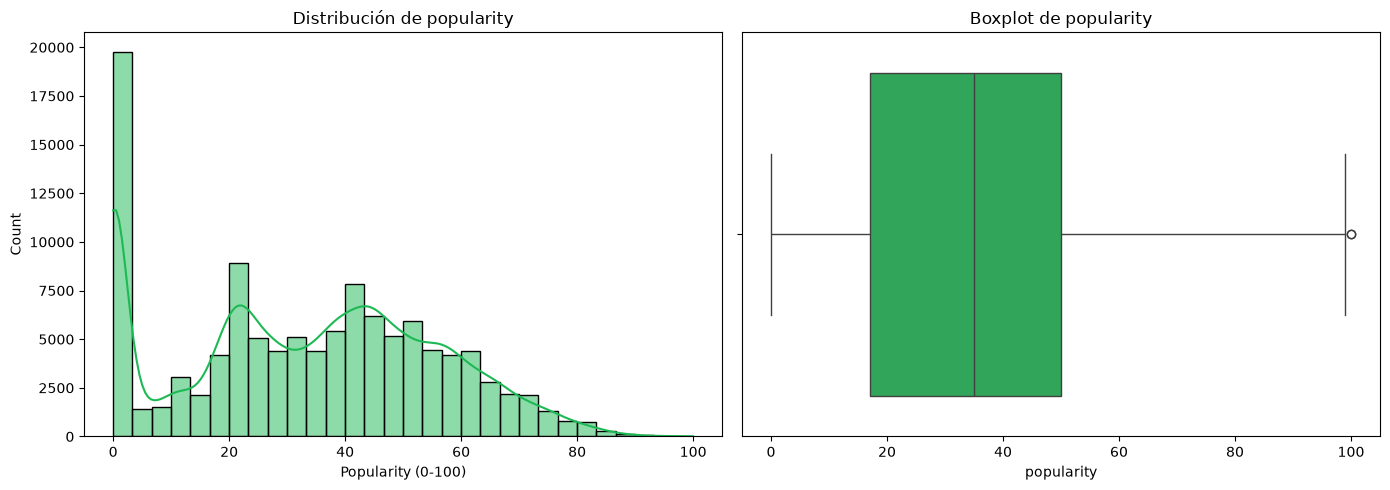

count    114000.000000
mean         33.238535
std          22.305078
min           0.000000
25%          17.000000
50%          35.000000
75%          50.000000
max         100.000000
Name: popularity, dtype: float64


In [10]:
#Análisis y visualización de la distribución de la popularidad (histograma y boxplot)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['popularity'], bins=30, kde=True, ax=axes[0], color='#1DB954')
axes[0].set_title('Distribución de popularity')
axes[0].set_xlabel('Popularity (0-100)')

sns.boxplot(x=df['popularity'], ax=axes[1], color='#1DB954')
axes[1].set_title('Boxplot de popularity')


plt.tight_layout()

# Guardar figura en la carpeta images/ del proyecto
# Define la ruta del directorio donde se guardarán las imágenes.
output_dir = 'images'
os.makedirs(output_dir, exist_ok=True)

plt.savefig(os.path.join(output_dir, 'distribucion_popularidad.png'), dpi=100, bbox_inches='tight')
plt.show()

print(df['popularity'].describe())

In [11]:
# Canciones con popularity = 0 (posible indicador de baja exposición o falta de datos)
pct_cero = df[df['popularity'] == 0].shape[0] / len(df) * 100
print(f"Canciones con popularity = 0: {pct_cero:.2f}%")

Canciones con popularity = 0: 14.05%


**Hallazgo:** la distribución de `popularity` es aproximadamente unimodal pero con una alta concentración de valores en 0, lo que sugiere una masa de canciones poco escuchadas o con poca información de Spotify. Este comportamiento debe considerarse en el modelamiento (ej. evaluar si se trata como regresión completa o si se filtran/tratan por separado los ceros).

## 4. Distribución de variables numéricas (Audio Features)

El objetivo es comprender cómo se distribuyen las principales características musicales de las canciones en la plataforma.

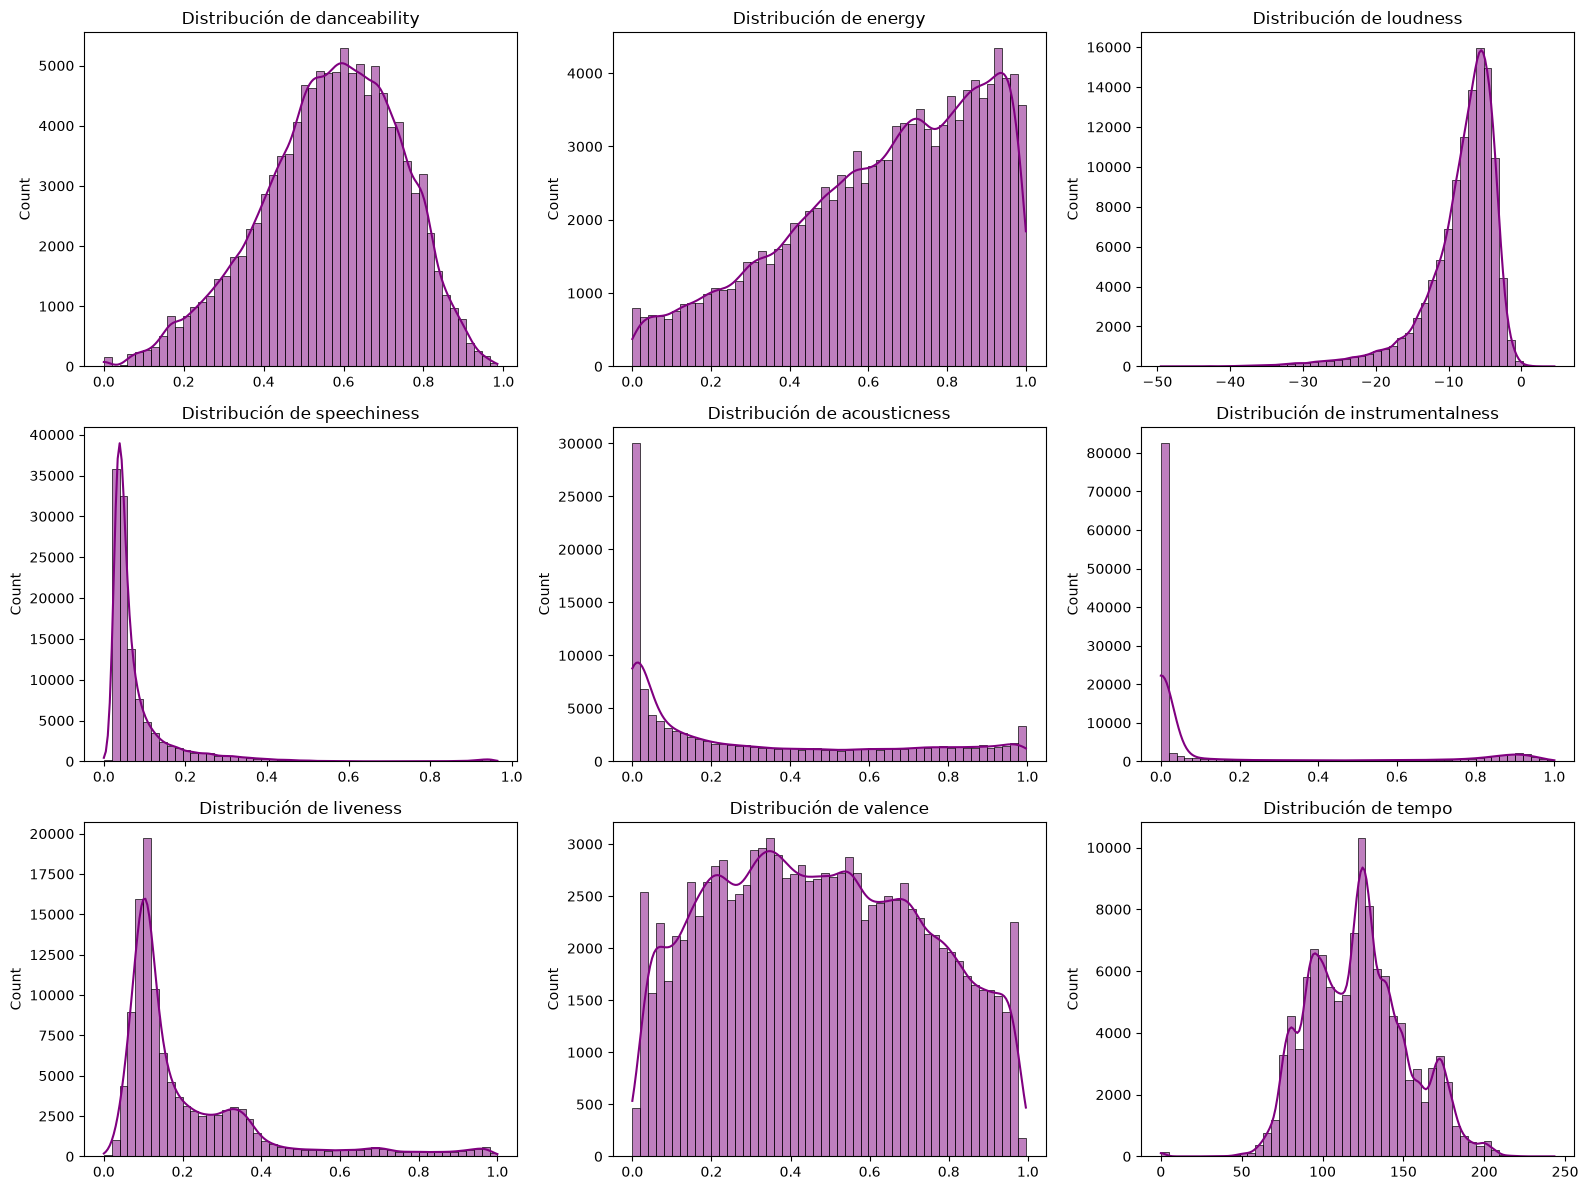

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

features = ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 
            'instrumentalness', 'liveness', 'valence', 'tempo']

plt.figure(figsize=(16, 12))
for i, feature in enumerate(features, 1):
    plt.subplot(3, 3, i)
    sns.histplot(df[feature], bins=50, kde=True, color='purple')
    plt.title(f'Distribución de {feature}')
    plt.xlabel('')

plt.tight_layout()
plt.savefig('images/distribucion_audio_features.png')
plt.show()

## 5. Detección de Valores Atípicos (Outliers)

Utilizamos boxplots para identificar posibles valores extremos en las características musicales.

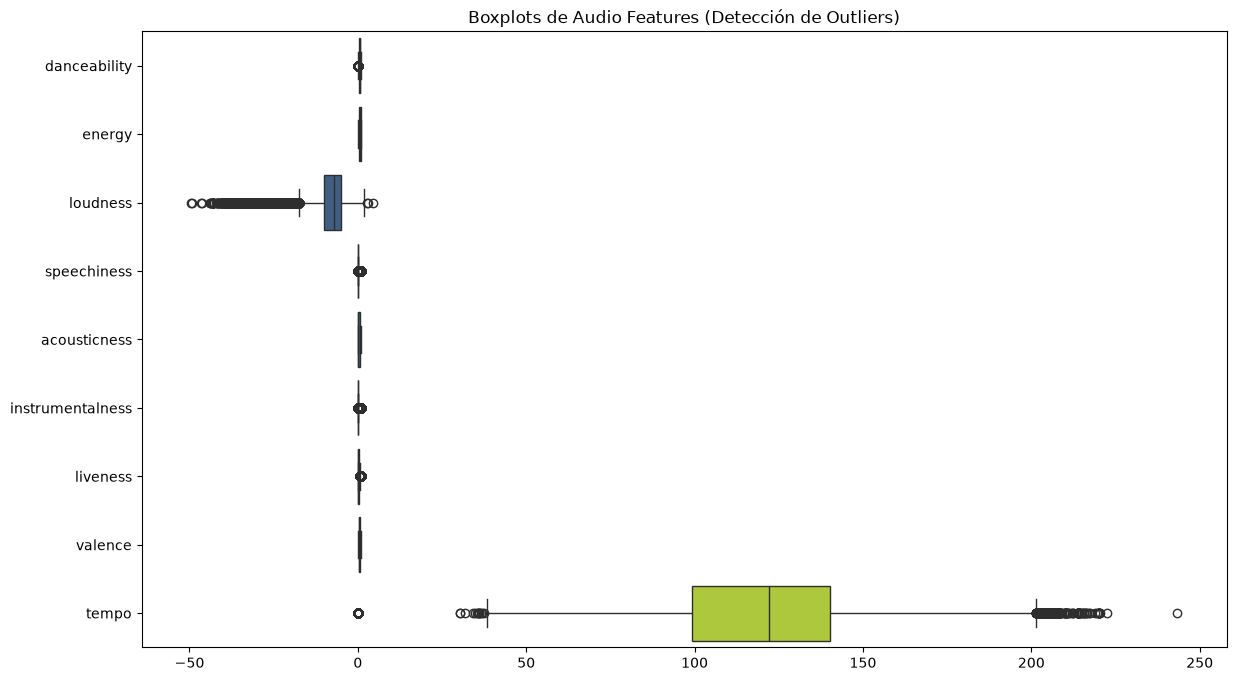

In [13]:
plt.figure(figsize=(14, 8))
sns.boxplot(data=df[features], orient='h', palette='viridis')
plt.title('Boxplots de Audio Features (Detección de Outliers)')
plt.savefig('images/outliers_boxplots.png')
plt.show()

**Hallazgo:** Existen valores extremos (outliers) particularmente en `instrumentalness`, `speechiness` y `liveness`, que presentan distribuciones fuertemente sesgadas hacia cero. Se requerirá transformación (ej. logarítmica) antes del modelamiento para modelos sensibles a la distribución.

## 6. Matriz de Correlaciones

Analizamos cómo se relacionan linealmente las variables entre sí, en particular con nuestra variable objetivo `popularity`.

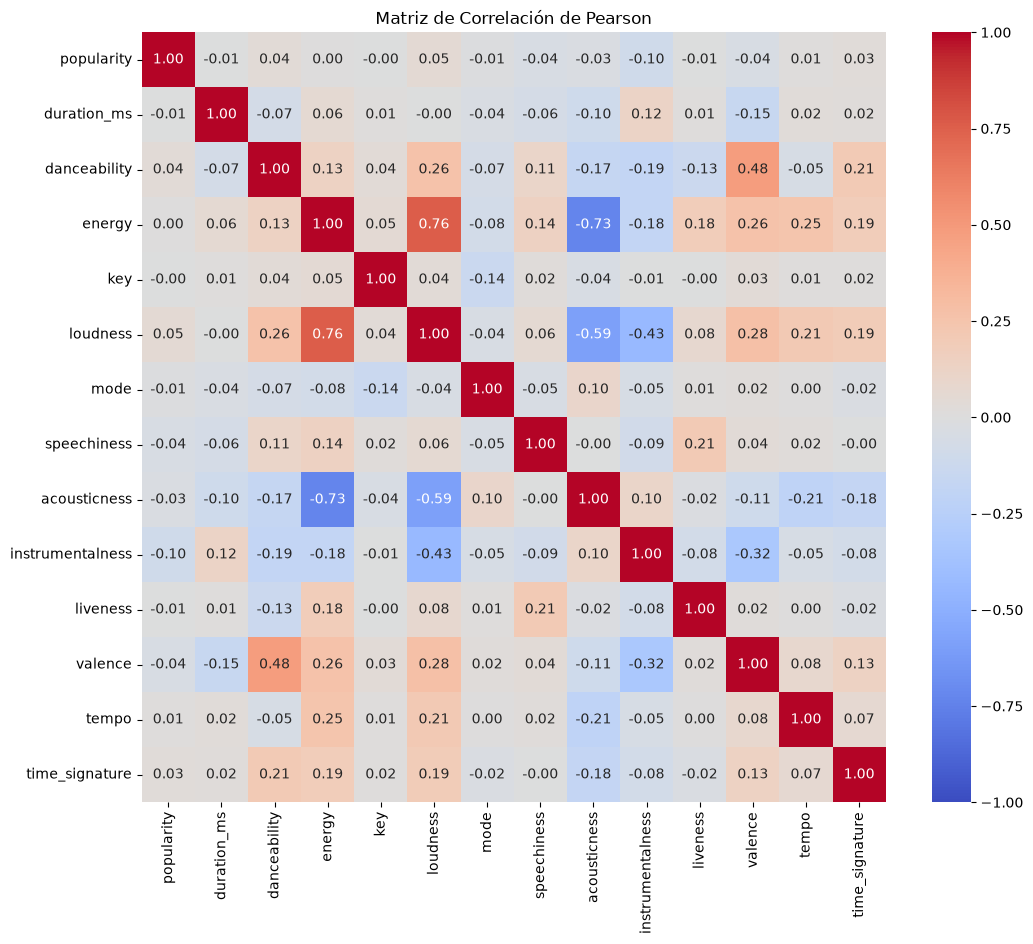

In [14]:
numeric_df = df.select_dtypes(include=['float64', 'int64'])

plt.figure(figsize=(12, 10))
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Matriz de Correlación de Pearson')
plt.savefig('images/heatmap_correlaciones.png')
plt.show()

**Hallazgo:** 
- `energy` y `loudness` tienen una alta correlación positiva (+0.76).
- `energy` y `acousticness` tienen una alta correlación negativa (-0.73).
- Ninguna feature de audio tiene una correlación lineal fuerte por sí sola con `popularity`, sugiriendo que la popularidad depende de interacciones más complejas o del género.

## 7. Análisis de variables categóricas: `track_genre` y `explicit`

Examinamos el impacto del género y el contenido explícito en la popularidad.

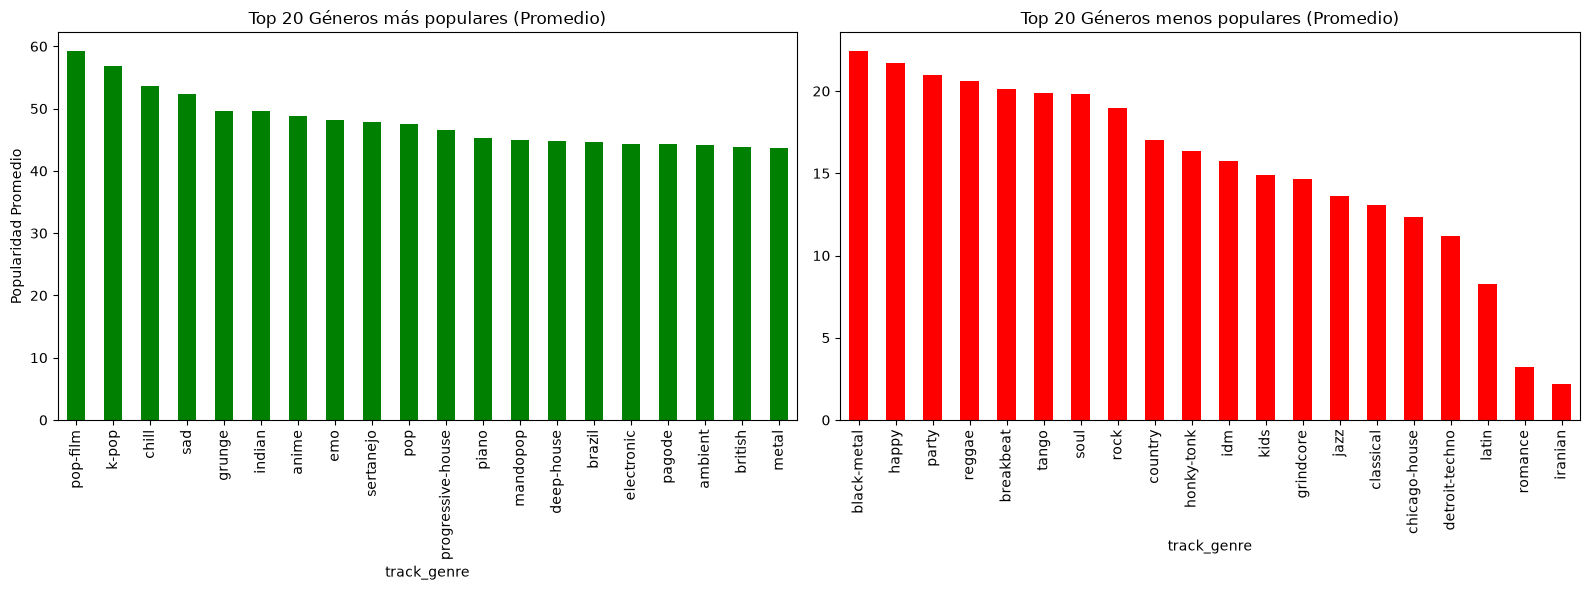

In [15]:
# Top 20 y Bottom 20 géneros por popularidad promedio
genre_pop = df.groupby('track_genre')['popularity'].mean().sort_values(ascending=False)

plt.figure(figsize=(16, 6))
plt.subplot(1, 2, 1)
genre_pop.head(20).plot(kind='bar', color='green')
plt.title('Top 20 Géneros más populares (Promedio)')
plt.ylabel('Popularidad Promedio')

plt.subplot(1, 2, 2)
genre_pop.tail(20).plot(kind='bar', color='red')
plt.title('Top 20 Géneros menos populares (Promedio)')

plt.tight_layout()
plt.savefig('images/popularidad_por_genero.png')
plt.show()

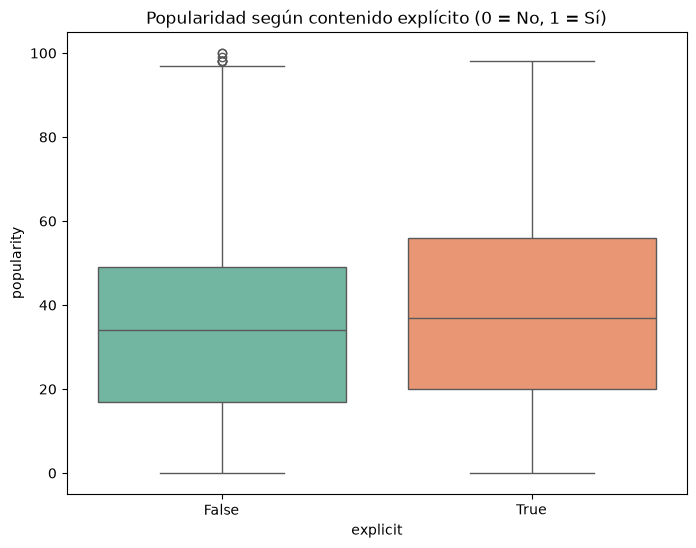

In [16]:
# Relación explícito vs popularidad
plt.figure(figsize=(8, 6))
sns.boxplot(x='explicit', y='popularity', data=df, palette='Set2')
plt.title('Popularidad según contenido explícito (0 = No, 1 = Sí)')
plt.savefig('images/popularidad_explicit.png')
plt.show()

**Hallazgo:** 
- El **género** es un discriminador muy fuerte de la popularidad. Hay géneros (ej. pop-film, k-pop, chill) con popularidad promedio alta, y otros (ej. iranio, romance, latin) que están casi en cero.
- Las canciones **explícitas** tienen una mediana de popularidad ligeramente mayor, lo que sugiere que es una variable relevante para el modelo.

## 8. Relación Features vs Popularity

Visualizamos la relación directa entre algunas features clave y la popularidad mediante gráficos de dispersión (usando una muestra aleatoria para no saturar el gráfico).

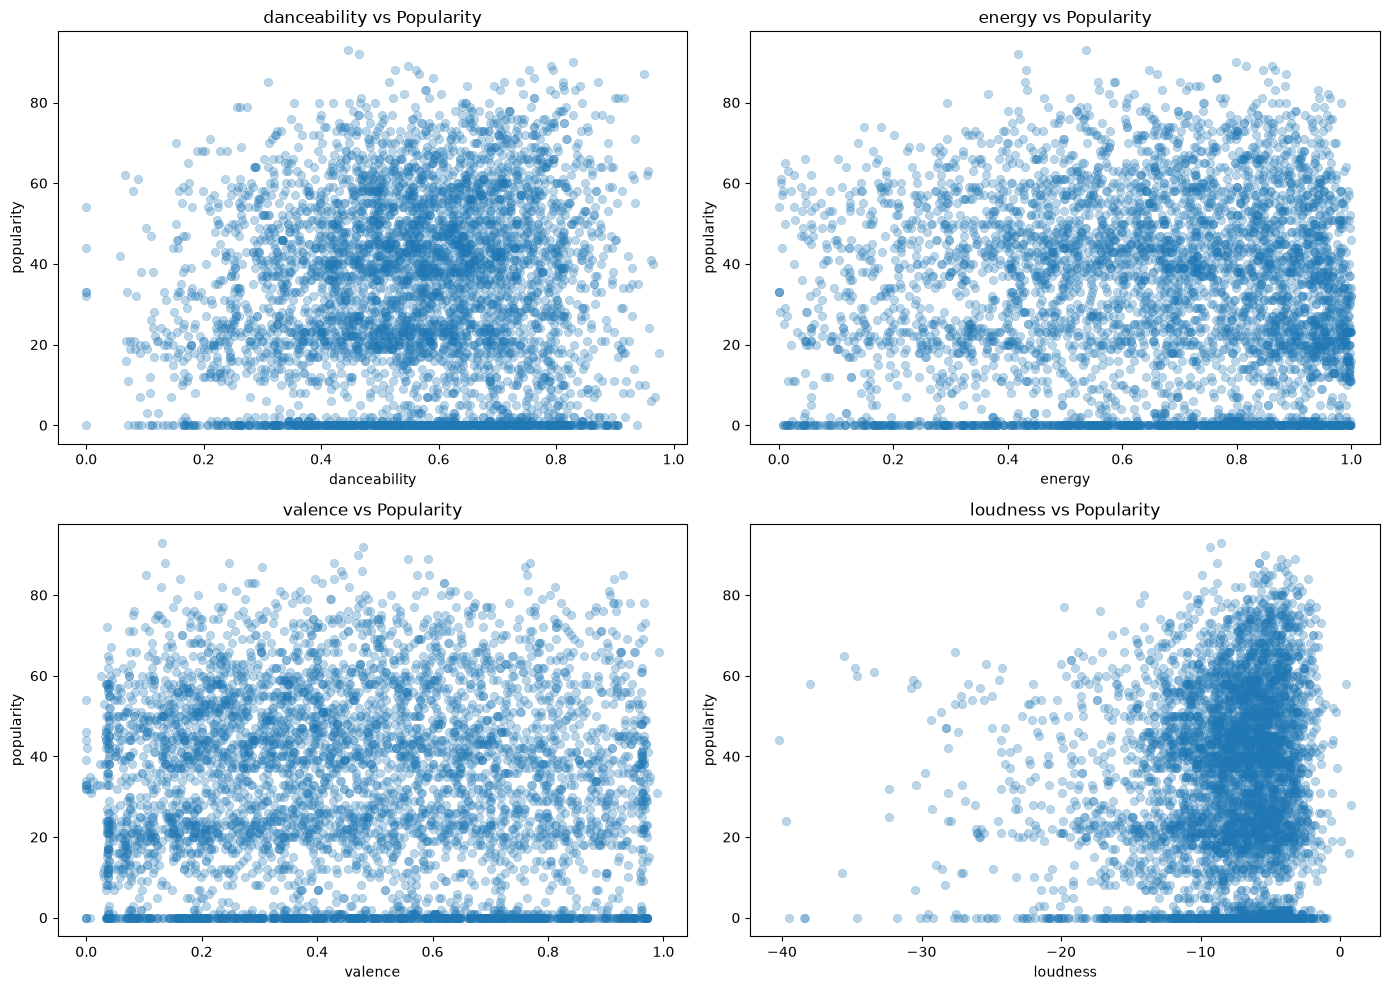

In [17]:
# Muestra aleatoria de 5000 registros para evitar overplotting
df_sample = df.sample(n=5000, random_state=SEED)

features_scatter = ['danceability', 'energy', 'valence', 'loudness']
plt.figure(figsize=(14, 10))
for i, feature in enumerate(features_scatter, 1):
    plt.subplot(2, 2, i)
    sns.scatterplot(x=df_sample[feature], y=df_sample['popularity'], alpha=0.3, edgecolor=None)
    plt.title(f'{feature} vs Popularity')

plt.tight_layout()
plt.savefig('images/scatter_features_vs_popularity.png')
plt.show()

**Hallazgo:** Como indicó la matriz de correlación, no hay relaciones lineales simples. La popularidad está dispersa a lo largo de todo el espectro de valores de las features, lo que hace necesario un modelo no lineal (ej. Random Forest, Gradient Boosting) para capturar estas relaciones.

## 9. Tabla de Valores Faltantes

Se presenta el resumen de valores nulos por columna. Dado que el dataset presenta muy pocos valores nulos (menos del 0.01%), no se requiere visualización adicional — la tabla es suficiente para documentar el hallazgo.

In [18]:
# Tabla resumen de valores nulos por columna
nulos = df.isnull().sum()
pct_nulos = (nulos / len(df) * 100).round(4)

tabla_nulos = pd.DataFrame({
    'Valores Nulos': nulos,
    'Porcentaje (%)': pct_nulos
}).sort_values('Valores Nulos', ascending=False)

# Mostrar solo columnas que tienen al menos un nulo
tabla_con_nulos = tabla_nulos[tabla_nulos['Valores Nulos'] > 0]

if tabla_con_nulos.empty:
    print("✅ El dataset no presenta valores nulos en ninguna columna.")
else:
    print(f"Columnas con valores nulos ({len(tabla_con_nulos)} de {df.shape[1]}):")
    display(tabla_con_nulos)

print(f"\nTotal de filas: {len(df):,} | Total de columnas: {df.shape[1]}")
print(f"Completitud general: {(1 - df.isnull().sum().sum() / df.size) * 100:.4f}%")

Columnas con valores nulos (3 de 20):


,Valores Nulos,Porcentaje (%)
artists,1,0.0009
album_name,1,0.0009
track_name,1,0.0009



Total de filas: 114,000 | Total de columnas: 20
Completitud general: 99.9999%


## 10. Síntesis y Decisiones basadas en el EDA

En base a la exploración, se toman las siguientes decisiones para la fase de Preparación de Datos:

1. **Valores nulos**: Son marginales (1 fila en `artists`, `album_name`, `track_name`). Se procederá a eliminar dichas filas.
2. **Duración inválida**: Se observó una canción con `duration_ms == 0`. Al ser un error de los datos, se eliminarán los registros con duración cero o extremadamente corta.
3. **Distribuciones asimétricas**: Variables como `speechiness`, `instrumentalness` y `liveness` tienen un sesgo muy fuerte. Se aplicará transformación logarítmica para acercarlas a una distribución normal.
4. **Variables predictoras relevantes**:
   - `track_genre` es fuertemente predictivo. Debe codificarse sin perderse.
   - `explicit` se mantendrá como variable binaria.
   - Las features numéricas se mantendrán pero se estandarizarán (`StandardScaler`).
5. **Multi-etiquetas de género**: Dado que una misma canción (`track_id`) aparece con distintos géneros, se mantendrán estas filas duplicadas por `track_id` pero con distinto `track_genre`, ya que el género impacta directamente la popularidad según la plataforma (una canción en un playlist de 'pop' tiene distinta tracción que en uno de 'acoustic').

---

## 11. Preparación y Transformación de Datos

Esta sección corresponde a la fase **Data Preparation** de la metodología CRISP-DM (IE2).  
Las decisiones se basan en los hallazgos del EDA (Sección 10):

1. Limpieza: nulos y valores inválidos.
2. Tratamiento de duplicados — **se conserva la granularidad canción-género** (`track_id` + `track_genre`), ya que un mismo `track_id` puede aparecer con múltiples géneros y el género es un predictor relevante.
3. Transformaciones logarítmicas para variables asimétricas.
4. Codificación de variables categóricas.
5. Estandarización de variables numéricas.
6. División Train / Test y guardado del dataset final.

### 11.1 Copia de trabajo

Se genera una copia del DataFrame original para preservar los datos crudos intactos.

In [19]:
df_prep = df.copy()
print(f"DataFrame de trabajo creado: {df_prep.shape[0]:,} filas x {df_prep.shape[1]} columnas")

DataFrame de trabajo creado: 114,000 filas x 20 columnas


### 11.2 Eliminación de valores nulos

Se eliminan las filas con nulos en columnas identificadoras de texto (`artists`, `album_name`, `track_name`). El impacto es mínimo (<0.01%).

In [20]:
filas_antes = len(df_prep)
df_prep = df_prep.dropna(subset=['artists', 'album_name', 'track_name'])
filas_eliminadas = filas_antes - len(df_prep)
print(f"Filas eliminadas por nulos: {filas_eliminadas} ({filas_eliminadas/filas_antes*100:.4f}%)")
print(f"Filas restantes: {len(df_prep):,}")

Filas eliminadas por nulos: 1 (0.0009%)
Filas restantes: 113,999


### 11.3 Eliminación de registros con duración inválida

Las canciones con `duration_ms = 0` son registros corruptos y se eliminan.

In [21]:
filas_antes = len(df_prep)
df_prep = df_prep[df_prep['duration_ms'] > 0]
filas_eliminadas = filas_antes - len(df_prep)
print(f"Filas eliminadas por duration_ms=0: {filas_eliminadas}")
print(f"Filas restantes: {len(df_prep):,}")

Filas eliminadas por duration_ms=0: 0
Filas restantes: 113,999


### 11.4 Tratamiento de duplicados

**Decisión clave:** Se mantiene la granularidad **canción-género** (`track_id` + `track_genre`).  
Un mismo `track_id` puede pertenecer a múltiples géneros en el dataset; como el género es un predictor relevante según el EDA, estas filas NO son duplicados reales — representan distintos contextos de una misma canción.  
Solo se eliminan duplicados exactos en **todas** las columnas.

In [22]:
filas_antes = len(df_prep)
df_prep = df_prep.drop_duplicates()
print(f"Duplicados exactos eliminados: {filas_antes - len(df_prep)}")
print(f"Filas restantes: {len(df_prep):,}")

# Verificar que track_id sigue teniendo múltiples géneros (esperado)
dup_track = df_prep.duplicated(subset=['track_id']).sum()
print(f"\nRegistros con track_id compartido (multi-género): {dup_track:,} — se conservan.")

Duplicados exactos eliminados: 450
Filas restantes: 113,549

Registros con track_id compartido (multi-género): 23,809 — se conservan.


### 11.5 Resumen de limpieza

In [23]:
print(f"{'Etapa':<35} {'Filas':>10}")
print("-" * 47)
print(f"{'Dataset original':<35} {len(df):>10,}")
print(f"{'Tras limpieza':<35} {len(df_prep):>10,}")
print(f"{'Filas eliminadas (total)':<35} {len(df) - len(df_prep):>10,}")
print(f"{'% datos conservados':<35} {len(df_prep)/len(df)*100:>10.2f}%")

Etapa                                    Filas
-----------------------------------------------
Dataset original                       114,000
Tras limpieza                          113,549
Filas eliminadas (total)                   451
% datos conservados                      99.60%


### 11.6 Transformaciones de variables

Se aplica `log1p` (logaritmo natural de 1+x) a las variables fuertemente sesgadas hacia 0:  
`speechiness`, `instrumentalness`, `liveness`, `duration_ms`.

In [24]:
import numpy as np

vars_log = ['speechiness', 'instrumentalness', 'liveness', 'duration_ms']

for col in vars_log:
    df_prep[f'{col}_log'] = np.log1p(df_prep[col])

print("Transformaciones log1p aplicadas:")
print(f"{'Variable':<22} {'Skew original':>15} {'Skew log':>12}")
print("-" * 50)
for col in vars_log:
    print(f"{col:<22} {df_prep[col].skew():>15.2f} {df_prep[col+'_log'].skew():>12.2f}")

Transformaciones log1p aplicadas:
Variable                 Skew original     Skew log
--------------------------------------------------
speechiness                       4.64         3.71
instrumentalness                  1.74         1.65
liveness                          2.11         1.74
duration_ms                      10.81        -0.32


### 11.7 Codificación de variables categóricas

- **`explicit`**: ya es binaria (0/1), no se modifica.
- **`track_genre`**: se codifica con **Label Encoding** (eficiente para modelos de árbol con 114 categorías).

In [25]:
from sklearn.preprocessing import LabelEncoder

le_genre = LabelEncoder()
df_prep['track_genre_encoded'] = le_genre.fit_transform(df_prep['track_genre'])

print(f"track_genre: {df_prep['track_genre'].nunique()} géneros codificados (0 a {df_prep['track_genre_encoded'].max()})")
print()
mapeo = list(zip(le_genre.classes_[:5], range(5)))
print("Muestra del mapeo (primeros 5):")
for genero, codigo in mapeo:
    print(f"  '{genero}' -> {codigo}")

track_genre: 114 géneros codificados (0 a 113)

Muestra del mapeo (primeros 5):
  'acoustic' -> 0
  'afrobeat' -> 1
  'alt-rock' -> 2
  'alternative' -> 3
  'ambient' -> 4


### 11.8 Estandarización (StandardScaler)

Se estandarizan las 15 features numéricas seleccionadas (media=0, std=1).

In [26]:
from sklearn.preprocessing import StandardScaler

features_modelo = [
    'danceability', 'energy', 'loudness', 'valence', 'tempo',
    'acousticness', 'mode', 'key', 'time_signature',
    'speechiness_log', 'instrumentalness_log', 'liveness_log', 'duration_ms_log',
    'explicit', 'track_genre_encoded'
]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_prep[features_modelo])
X = pd.DataFrame(X_scaled, columns=features_modelo, index=df_prep.index)
y = df_prep['popularity'].reset_index(drop=True)
X = X.reset_index(drop=True)

print(f"Features (X): {X.shape[0]:,} filas x {X.shape[1]} columnas")
print(f"Target  (y): {len(y):,} valores | rango: {y.min()}-{y.max()} | media: {y.mean():.2f}")
print()
print("Media y desv. estándar post-estandarización (deben ser ~0 y ~1):")
print(X.agg(['mean','std']).round(3).T.head(5).to_string())

Features (X): 113,549 filas x 15 columnas
Target  (y): 113,549 valores | rango: 0-100 | media: 33.32

Media y desv. estándar post-estandarización (deben ser ~0 y ~1):
              mean  std
danceability   0.0  1.0
energy         0.0  1.0
loudness       0.0  1.0
valence        0.0  1.0
tempo         -0.0  1.0


### 11.9 División Train / Test

Se divide el dataset en 80% entrenamiento y 20% prueba con `random_state=42` para reproducibilidad.

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)

print(f"Train: {X_train.shape[0]:,} filas ({X_train.shape[0]/len(X)*100:.0f}%) | "
      f"Test: {X_test.shape[0]:,} filas ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"Popularity train - media: {y_train.mean():.2f} | std: {y_train.std():.2f}")
print(f"Popularity test  - media: {y_test.mean():.2f}  | std: {y_test.std():.2f}")

Train: 90,839 filas (80%) | Test: 22,710 filas (20%)
Popularity train - media: 33.34 | std: 22.26
Popularity test  - media: 33.26  | std: 22.40


### 11.10 Guardado del dataset procesado

In [28]:
import os
os.makedirs('data/processed', exist_ok=True)

df_prep.to_csv('data/processed/spotify_clean.csv', index=False)
X.to_csv('data/processed/X_model.csv', index=False)
y.to_csv('data/processed/y_model.csv', index=False, header=True)

print("Archivos guardados en data/processed/:")
for fname in ['spotify_clean.csv', 'X_model.csv', 'y_model.csv']:
    path = f'data/processed/{fname}'
    kb = os.path.getsize(path) // 1024
    print(f"  {fname:<25} {kb:>6} KB")

Archivos guardados en data/processed/:
  spotify_clean.csv          27512 KB
  X_model.csv                32791 KB
  y_model.csv                  421 KB


In [29]:
# Comparativa estadística de estabilidad: Dataset Crudo vs. Dataset Preparado
comp_data = {
    'Métrica / Variable': [
        'Filas totales',
        'Popularidad Media',
        'Popularidad Mediana',
        '% Popularidad = 0',
        'Bailabilidad (danceability) Media',
        'Habla (speechiness) Media',
        'Correlación danceability vs. popularity',
        'Correlación energy vs. loudness'
    ],
    'Crudo (df)': [
        f"{len(df):,}",
        f"{df['popularity'].mean():.2f}",
        f"{df['popularity'].median():.1f}",
        f"{(df['popularity'] == 0).sum() / len(df) * 100:.2f}%",
        f"{df['danceability'].mean():.3f}",
        f"{df['speechiness'].mean():.3f}",
        f"{df['danceability'].corr(df['popularity']):.3f}",
        f"{df['energy'].corr(df['loudness']):.3f}"
    ],
    'Limpio (df_prep)': [
        f"{len(df_prep):,}",
        f"{df_prep['popularity'].mean():.2f}",
        f"{df_prep['popularity'].median():.1f}",
        f"{(df_prep['popularity'] == 0).sum() / len(df_prep) * 100:.2f}%",
        f"{df_prep['danceability'].mean():.3f}",
        f"{df_prep['speechiness'].mean():.3f}",
        f"{df_prep['danceability'].corr(df_prep['popularity']):.3f}",
        f"{df_prep['energy'].corr(df_prep['loudness']):.3f}"
    ],
    'Variación': [
        f"{len(df_prep) - len(df):,} (-{(len(df) - len(df_prep)) / len(df) * 100:.2f}%)",
        f"{df_prep['popularity'].mean() - df['popularity'].mean():+.2f} pts",
        "0.0 pts",
        f"{(df_prep['popularity'] == 0).sum() / len(df_prep) * 100 - (df['popularity'] == 0).sum() / len(df) * 100:+.2f}%",
        f"{df_prep['danceability'].mean() - df['danceability'].mean():+.3f}",
        f"{df_prep['speechiness'].mean() - df['speechiness'].mean():+.3f}",
        f"{df_prep['danceability'].corr(df_prep['popularity']) - df['danceability'].corr(df['popularity']):+.3f}",
        f"{df_prep['energy'].corr(df_prep['loudness']) - df['energy'].corr(df['loudness']):+.3f}"
    ],
    'Diagnóstico Metodológico': [
        'Depuración mínima conservadora',
        'Sin sesgo inducido',
        'Mediana intacta',
        'Masa en cero preservada',
        'Distribución acústica intacta',
        'Asimetría física real confirmada',
        'Mito caído confirmado',
        'Colinealidad idéntica'
    ]
}

df_comparativa = pd.DataFrame(comp_data)
display(df_comparativa)
print("Conclusión: La limpieza (depuración del 0.40%) no distorsionó ninguna propiedad estadística del dataset.")

,Métrica / Variable,Crudo (df),Limpio (df_prep),Variación,Diagnóstico Metodológico
0,Filas totales,"114,000","113,549",-451 (-0.40%),Depuración mínima conservadora
1,Popularidad Media,33.24,33.32,+0.09 pts,Sin sesgo inducido
2,Popularidad Mediana,35.0,35.0,0.0 pts,Mediana intacta
3,% Popularidad = 0,14.05%,13.95%,-0.10%,Masa en cero preservada
4,Bailabilidad (danceability) Media,0.567,0.567,+0.000,Distribución acústica intacta
5,Habla (speechiness) Media,0.085,0.085,+0.000,Asimetría física real confirmada
6,Correlación danceability vs. popularity,0.035,0.034,-0.001,Mito caído confirmado
7,Correlación energy vs. loudness,0.762,0.761,-0.001,Colinealidad idéntica


Conclusión: La limpieza (depuración del 0.40%) no distorsionó ninguna propiedad estadística del dataset.


### Síntesis de la preparación de datos

| Etapa | Acción | Resultado |
|-------|--------|-----------|
| **Nulos** | Eliminar filas nulas en columnas de texto | Impacto < 0.01% |
| **Valores inválidos** | Eliminar `duration_ms = 0` | Registros corruptos eliminados |
| **Duplicados** | Eliminar duplicados exactos; conservar multi-género | Granularidad canción-género preservada |
| **Transformación log** | `log1p` en 4 variables sesgadas | Reducción de asimetría |
| **Codificación** | Label Encoding en `track_genre` (114 géneros) | Lista para modelos de árbol |
| **Estandarización** | `StandardScaler` en 15 features | Media ≈ 0, Std ≈ 1 |
| **División** | 80% train / 20% test (`random_state=42`) | Separación reproducible |


#### Validación de Estabilidad Post-Limpieza (Crudo vs. Limpio)

La comparativa estadística demuestra empíricamente que la eliminación del **0.40%** de registros (1 fila nula + 450 duplicados exactos) **no alteró ninguna de las propiedades fundamentales** descubiertas en el EDA: la mediana de popularidad se mantiene en 35.0, la concentración en cero en ~14.0%, las medias de los features acústicos no varían y las correlaciones lineales son idénticas al tercer decimal. Esto garantiza que los hallazgos del análisis exploratorio son estructurales y que la limpieza fue puramente conservadora y libre de sesgo inducido.

---

## Evaluación de Sesgos, Ética y Privacidad de los Datos

### Privacidad y origen de los datos

| Aspecto | Evaluación |
|---------|------------|
| **Datos personales** | ❌ No contiene. Solo metadatos de canciones (nombre, género, features de audio). |
| **Origen** | API pública de Spotify. Publicado en Kaggle bajo licencia académica. |
| **Ley aplicable (Chile)** | Ley 19.628 sobre Protección de la Vida Privada — **No aplica** al no haber datos personales. |
| **Regulación internacional** | GDPR (UE) — **No aplica** por la misma razón. |

---

### Sesgos identificados en el dataset

#### 1.  Sesgo de exposición algorítmica
`popularity` no mide valor artístico, sino reproducciones recientes dentro de Spotify. Canciones promovidas algorítmicamente por la plataforma tendrán puntajes más altos independientemente de su calidad musical. Un modelo entrenado con estos datos puede **replicar y amplificar ese sesgo**.

#### 2.  Sesgo geográfico y lingüístico
Spotify tiene mayor penetración en mercados anglosajones y europeos. El dataset no incluye metadatos de idioma ni región. Géneros de música latinoamericana, asiática o africana pueden estar subrepresentados en los scores de popularidad alta.

#### 3.  Sesgo de representación de géneros
El dataset contiene exactamente ~1.000 canciones por género (distribución artificial). No refleja la producción real por género ni la proporción real en el catálogo de Spotify.

#### 4.  Sesgo de popularidad acumulada
El score refleja streams **recientes**. Canciones más antiguas, aunque históricamente exitosas, pueden tener puntajes bajos. El modelo podría subestimar sistemáticamente la popularidad de música clásica o de décadas anteriores.

#### 5.  Sesgo de contenido explícito
Canciones con `explicit=True` presentan una mediana de popularidad ligeramente más alta, lo que puede generar una asociación espuria. La relación real depende del género y el artista, no del contenido explícito per se.

---

### Implicaciones éticas del uso del modelo

1. **Refuerzo de desigualdades**: un modelo entrenado con datos históricos de Spotify podría perpetuar la ventaja de artistas ya establecidos, dificultando la visibilidad de artistas emergentes con características musicales similares.
2. **Decisiones de inversión sesgadas**: si el modelo se usara para decidir qué artistas financiar, sus predicciones podrían convertirse en una barrera de entrada para géneros o artistas subrepresentados.
3. **Reduccionismo musical**: predecir el éxito solo por features de audio ignora factores contextuales clave (momento cultural, redes sociales, historia del artista) centrales al fenómeno de la popularidad.

---

> **Conclusión ética:** El modelo desarrollado en este proyecto tiene valor académico y exploratorio. Su uso en decisiones de negocio reales requeriría auditorías de sesgo, mayor diversidad de datos y validación con expertos del dominio musical.